In [5]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import glob
import sys
import pdb
sys.path.insert(1, '/Users/joe/repos/climate_utils')
import climate_toolbox as ctb
%matplotlib inline
from datetime import datetime
from scipy.optimize import curve_fit
from matplotlib.patches import Rectangle
from matplotlib.colors import BoundaryNorm

import OCO_v11MIP_analysis as oco

In [2]:
# -------- get all simulations in the MIP ----------
pdir = 'processed_data'
all_runs = glob.glob(f'{loc}/{mip}/*.nc4')

# -------- get all models and observational sets ----------
all_models = sorted(np.unique([run.split('/')[-1].split('_')[0] for run in all_runs]))
all_obs    = sorted(np.unique([run.split('/')[-1].split('_')[-1].strip('.nc4') for run in all_runs]))
gc_models  = ['Ames', 'CMS-Flux', 'GCAS', 'JHU', 'WOMBAT-GC']
N_gc       = len(gc_models)
tm5_models = ['CT', 'CT-MP', 'TM5-4DVAR', 'WOMBAT-TM5']
N_tm5      = len(gc_models)

# -------- build model dictionary ----------
models = {}
for model in all_models:
    models[model] = {}
    for obs in all_obs:
        models[model][obs] = glob.glob(f'{loc}/{mip}/*{model}*_{obs}*.nc4')[0]
N = len(all_models)

# -------- get all flux components ----------
all_fluxes  = sorted(list(xr.open_dataset(models['WOMBAT-GC']['LNLGIS']).data_vars))[1:]
flux_colors = ['indianred', 'yellowgreen', 'cornflowerblue']

print(all_models)
print(all_obs)
print(all_fluxes)

NameError: name 'glob' is not defined

In [ ]:
overwrite=False

ens          = {}
ens_gc       = {}
ens_tm5      = {}
ens_mean     = {}
ens_gc_mean  = {}
ens_tm5_mean = {}
ens_std      = {}
ens_gc_std   = {}
ens_tm5_std  = {}

# -------- get ensemble means
for obs in all_obs:

    # ---- full ensemble
    ens[obs] = xr.concat([xr.open_dataset(models[model][obs]) for model in all_models], 
                          dim=xr.DataArray(all_models, dims="model", name="model"))
    try:
        if(overwrite): raise FileNotFoundError
        ens_mean[obs] = xr.open_dataset(f'{loc}/{pdir}/ens_{obs}.nc4')
        ens_std[obs]  = xr.open_dataset(f'{loc}/{pdir}/ens_std_{obs}.nc4')
        print(f'read ensemble mean for {obs} from file')
    except FileNotFoundError:
        print(f'computing ensemble mean for {obs}')
        ens[obs] = xr.concat([xr.open_dataset(models[model][obs]) for model in all_models], 
                        dim=xr.DataArray(all_models, dims="model", name="model"))
        
        ens_std[obs]  = ens[obs].std('model')
        ens_std[obs].to_netcdf(f'{loc}/{pdir}/ens_std_{obs}.nc4')
        ens_mean[obs] = ens[obs].mean('model')
        ens_mean[obs].to_netcdf(f'{loc}/{pdir}/ens_{obs}.nc4')

    # ---- GC ensemble
    ens_gc[obs] = xr.concat([xr.open_dataset(models[model][obs]) for model in gc_models], 
                             dim=xr.DataArray(gc_models, dims="model", name="model"))
    try:
        if(overwrite): raise FileNotFoundError
        ens_gc_mean[obs] = xr.open_dataset(f'{loc}/{pdir}/ens_gc_{obs}.nc4')
        ens_gc_std[obs]  = xr.open_dataset(f'{loc}/{pdir}/ens_gc_std_{obs}.nc4')
        print(f'read GC ensemble mean for {obs} from file')
    except FileNotFoundError:
        print(f'computing GC ensemble mean for {obs}')
        ens_gc_std[obs]  = ens_gc[obs].std('model')
        ens_gc_std[obs].to_netcdf(f'{loc}/{pdir}/ens_gc_std_{obs}.nc4')
        ens_gc_mean[obs] = ens_gc[obs].mean('model')
        ens_gc_mean[obs].to_netcdf(f'{loc}/{pdir}/ens_gc_{obs}.nc4')

    # ---- TM5 ensemble
    ens_tm5[obs] = xr.concat([xr.open_dataset(models[model][obs]) for model in tm5_models], 
                              dim=xr.DataArray(tm5_models, dims="model", name="model"))
    try:
        if(overwrite): raise FileNotFoundError
        ens_tm5_mean[obs] = xr.open_dataset(f'{loc}/{pdir}/ens_tm5_{obs}.nc4')
        ens_tm5_std[obs]  = xr.open_dataset(f'{loc}/{pdir}/ens_tm5_std_{obs}.nc4')
        print(f'read TM5 ensemble mean for {obs} from file')
    except FileNotFoundError:
        print(f'computing TM5 ensemble mean for {obs}')
        ens_tm5_std[obs]  = ens_tm5[obs].std('model')
        ens_tm5_std[obs].to_netcdf(f'{loc}/{pdir}/ens_tm5_std_{obs}.nc4')
        ens_tm5_mean[obs] = ens_tm5[obs].mean('model')
        ens_tm5_mean[obs].to_netcdf(f'{loc}/{pdir}/ens_tm5_{obs}.nc4')

print('done')

working on ocean_flux flux
working on land_flux flux
working on ocean_flux flux
working on land_flux flux


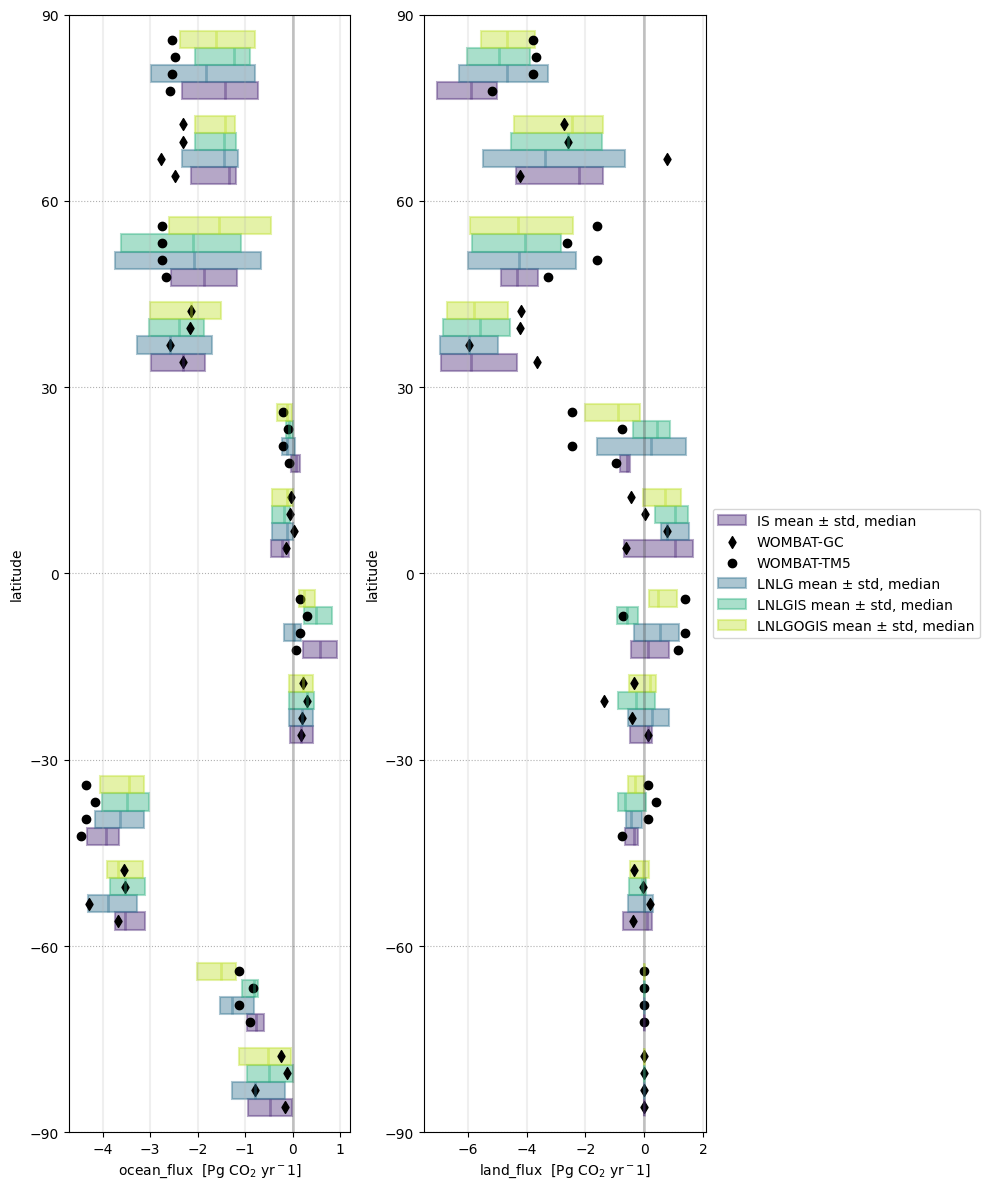

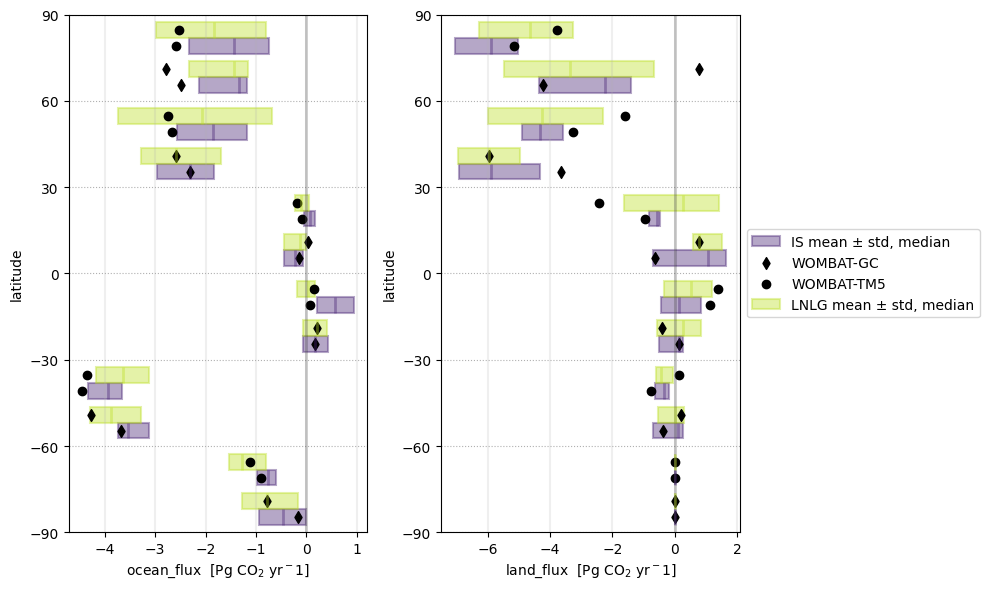

In [4]:
# ---------- compute net climatological fluxes per latitude band, as ensemble mean, transport ensemble means, WOMBAT

def make_avgflux_bands_plot(include_obs, fname):
    # ----- define latitude bands
    dlat  = 30
    latS  = np.arange(-90, 90-dlat+1, dlat)
    latN  = np.arange(-90+dlat, 90+1, dlat)
    latc  = np.arange(-90+dlat/2, 90-dlat/2 + 1, dlat)
    
    include_ensmean = False
    if(include_ensmean): ng = 3
    else:                ng = 2
    
    Nobs  = len(include_obs)
    pad   = 8
    ddlat = dlat/(Nobs*ng) - pad/(Nobs*ng)
    
    # ----- defined colors per obs set
    colors = np.atleast_1d(plt.cm.viridis(np.linspace(0.1, 0.9, Nobs)))
    
    # ----- create figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 12 * len(include_obs)/4))
    
    # ----- compute medians and deviations for model groups in bands
    for k,flux in enumerate(['ocean_flux', 'land_flux']):
        print(f'working on {flux} flux')
        ax = axes[k]
        ax.yaxis.set_ticks(np.unique(np.hstack([latS, latN])))
        ax.set_ylim([-90, 90])
        ax.grid(axis='y', linestyle=':')
        ax.grid(axis='x', linestyle='-', alpha=0.2, lw=1.5)
        ax.axvline(x=0, linestyle='-', color='k', lw=2, alpha=0.2)
        ax.set_xlabel(f'{flux}  [Pg CO$_2$ yr$^{-1}$]')
        ax.set_ylabel('latitude')
        
        for i in range(len(latS)):
            print(f'working on lat band {i}', end='\r')
            
            for j,obs in enumerate(include_obs):
                if obs == 'Prior': continue
    
                # select on obs, flux, take band mean, take time mean, scale to PgC/yr
                band_ens     = horz_avg(ens[obs][flux].sel(latitude=slice(latS[i], latN[i])))* 100
                band_gc_ens  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(latS[i], latN[i]))) * 100
                band_tm5_ens = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(latS[i], latN[i]))) * 100
    
                # get time mean, 2015-2019
                band_ens = band_ens.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
                band_gc_ens = band_gc_ens.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
                band_tm5_ens = band_tm5_ens.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
    
                if(include_ensmean):
                    band_ens_all = [band_gc_ens, band_tm5_ens, band_ens]
                else:
                    band_ens_all = [band_gc_ens, band_tm5_ens]
    
                for l in range(ng):
                    # get medians, deviations, lower y-position of bar
                    y = latS[i] + (j+l*Nobs)*ddlat + pad/(ng+1) * (l+1)
                    x  = float(band_ens_all[l].median('model'))
                    xm = float(band_ens_all[l].mean('model')) 
                    xe = float(band_ens_all[l].std('model'))
        
                    # get colors
                    fcolor = colors[j]
                    fcolor[-1] = 0.4
                    ecolor = colors[j]

                    # get labels
                    if(i==0 and k==1 and l==0): label = f'{obs} mean ± std, median'
                    else:     label = None
        
                    # rectangle showing uncertainty and median
                    rect = Rectangle(
                           (xm - xe, y),  # bottom-left corner
                           2*xe, ddlat,  # width and height
                           facecolor=fcolor, edgecolor=ecolor, linewidth=1.5, label=label)
                    ax.add_patch(rect)
                    # center vertical line
                    ax.vlines(x, y, y+ddlat, color=ecolor, linewidth=2)
    
                    # plot WOMBAT
                    y = y + ddlat/2
                    if(l==0):   
                        x = band_ens.sel(model='WOMBAT-GC')
                        marker='d'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-GC'
                        else:              label = None
                    elif(l==1): 
                        x = band_ens.sel(model='WOMBAT-TM5')
                        marker='o'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-TM5'
                        else:              label = None
                    else:
                        x = 0
                        marker=''
                    ax.scatter(x, y, color='k', marker=marker, label=label)

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    fig.savefig(f'{fname}.png', dpi=200)
                    
# -------------------------------------------------
# --------- call function and make plots ----------
make_avgflux_bands_plot(['IS', 'LNLG', 'LNLGIS', 'LNLGOGIS'], fname='avgflux_bands_allobs')
make_avgflux_bands_plot(['IS', 'LNLG'], fname='avgflux_bands_IS_LNLG')

working on ocean_flux flux
working on land_flux flux
working on ocean_flux flux
working on land_flux flux


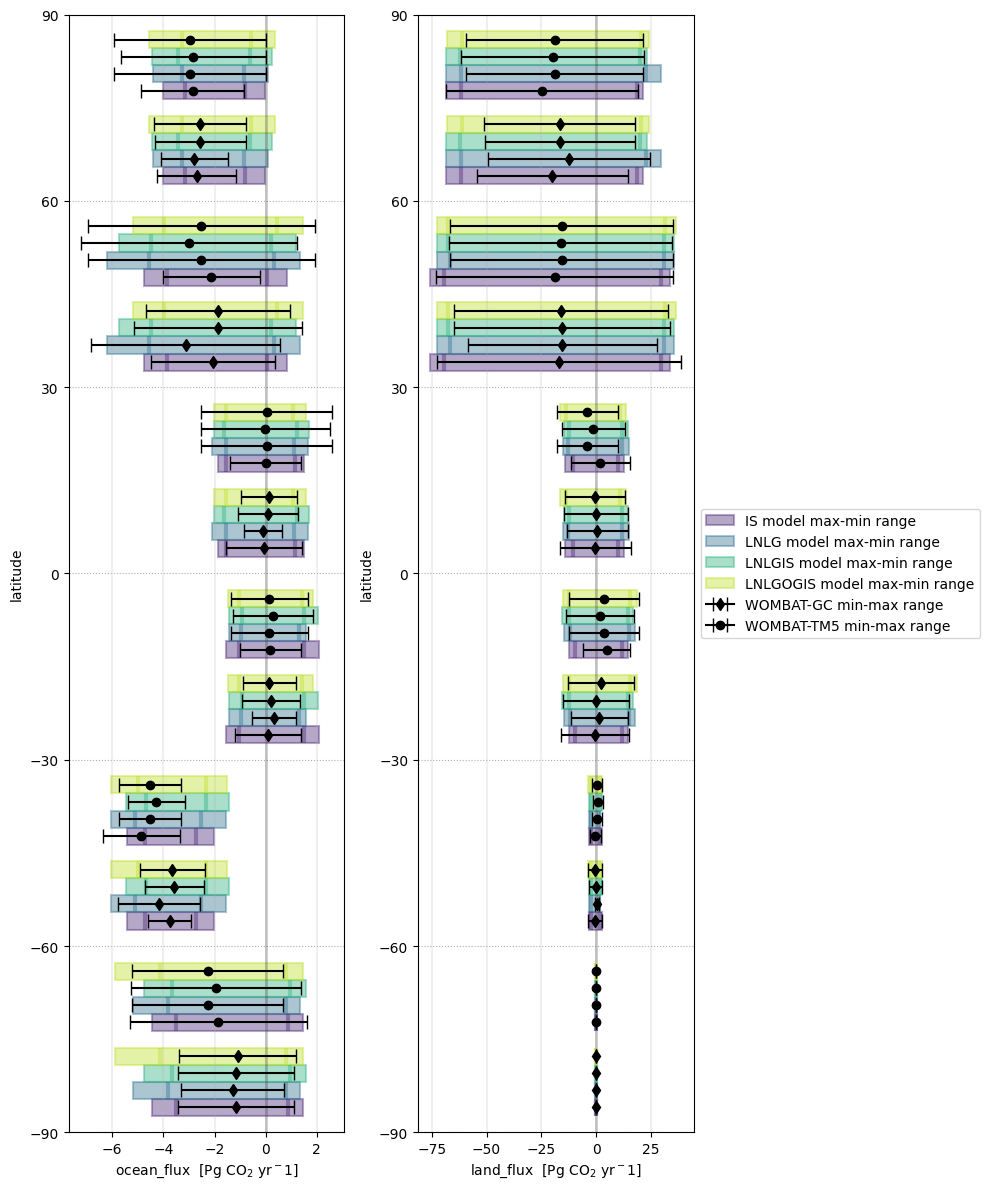

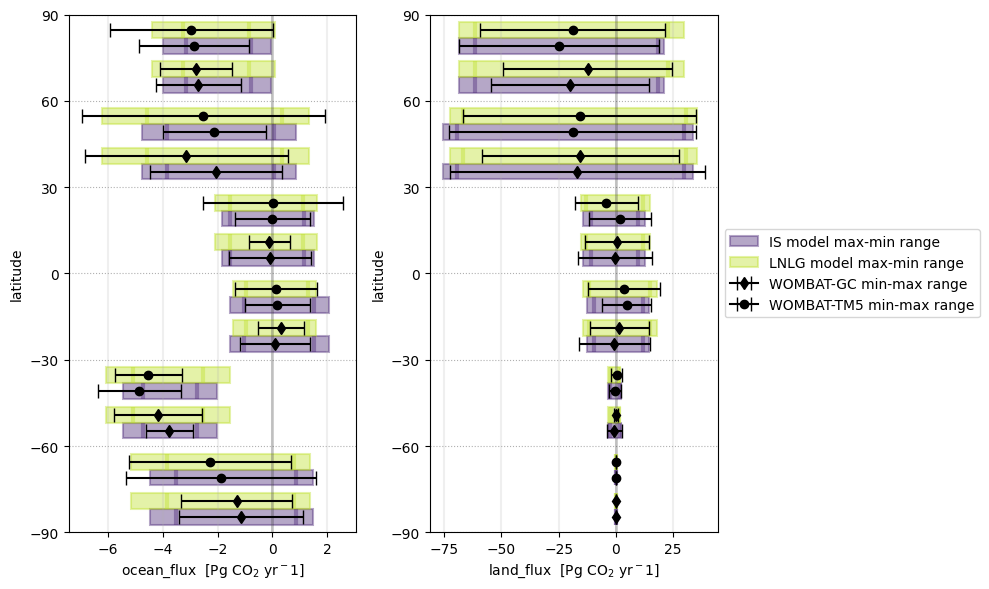

In [5]:
# ---------- compute net climatological fluxes per latitude band, as ensemble mean, transport ensemble means, WOMBAT

def make_fluxrange_bands_plot(include_obs, fname):
    # ----- define latitude bands
    dlat  = 30
    latS  = np.arange(-90, 90-dlat+1, dlat)
    latN  = np.arange(-90+dlat, 90+1, dlat)
    latc  = np.arange(-90+dlat/2, 90-dlat/2 + 1, dlat)
    
    include_ensmean = False
    if(include_ensmean): ng = 3
    else:                ng = 2
    
    Nobs  = len(include_obs)
    pad   = 8
    ddlat = dlat/(Nobs*ng) - pad/(Nobs*ng)
    
    # ----- defined colors per obs ser
    colors = np.atleast_1d(plt.cm.viridis(np.linspace(0.1, 0.9, Nobs)))
    
    # ----- create figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 12 * len(include_obs)/4))
    
    # ----- compute medians and deviations for model groups in bands
    for k,flux in enumerate(['ocean_flux', 'land_flux']):
        print(f'working on {flux} flux')
        ax = axes[k]
        ax.yaxis.set_ticks(np.unique(np.hstack([latS, latN])))
        ax.set_ylim([-90, 90])
        ax.grid(axis='y', linestyle=':')
        ax.grid(axis='x', linestyle='-', alpha=0.2, lw=1.5)
        ax.axvline(x=0, linestyle='-', color='k', lw=2, alpha=0.2)
        ax.set_xlabel(f'{flux}  [Pg CO$_2$ yr$^{-1}$]')
        ax.set_ylabel('latitude')
        
        for i in range(len(latS)):
            print(f'working on lat band {i}', end='\r')
            
            for j,obs in enumerate(include_obs):
                if obs == 'Prior': continue
    
                # select on obs, flux, take band mean, take time mean, scale to PgC/yr
                band_ens     = horz_avg(ens[obs][flux].sel(latitude=slice(latS[i], latN[i])))* 100
                band_gc_ens  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(latS[i], latN[i]))) * 100
                band_tm5_ens = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(latS[i], latN[i]))) * 100

                # get climatology
                band_ens_climo     = ctb.compute_climatology(band_ens)
                band_gc_ens_climo  = ctb.compute_climatology(band_ens)
                band_tm5_ens_climo = ctb.compute_climatology(band_ens)
    
                if(include_ensmean):
                    band_ens_all = [band_gc_ens_climo, band_tm5_ens_climo, band_ens_climo]
                else:
                    band_ens_all = [band_gc_ens_climo, band_tm5_ens_climo]
    
                for l in range(ng):
                    # get medians, deviations, lower y-position of bar
                    y = latS[i] + (j+l*Nobs)*ddlat + pad/(ng+1) * (l+1)
                    xmax, xmaxe = float(band_ens_all[l].max('month').mean('model')),\
                                  float(band_ens_all[l].max('month').std('model'))
                    xmin, xmine = float(band_ens_all[l].min('month').mean('model')),\
                                  float(band_ens_all[l].min('month').std('model'))
                    
                    # get colors
                    fcolor = colors[j]
                    fcolor[-1] = 0.4
                    ecolor = colors[j]

                    # get labels
                    if(i==0 and k==1 and l==0): label = f'{obs} model max-min range'
                    else:     label = None
        
                    # rectangle showing uncertainty and median
                    rect = Rectangle(
                           (xmin-xmine, y),                   # bottom-left corner
                           (xmax+xmaxe)-(xmin-xmine), ddlat,  # width and height
                           facecolor=fcolor, edgecolor=ecolor, linewidth=1.5, label=label)
                    ax.add_patch(rect)
                    # center vertical line
                    ax.vlines(xmin, y, y+ddlat, color=ecolor, linewidth=3)
                    ax.vlines(xmax, y, y+ddlat, color=ecolor, linewidth=3)
    
                    # plot WOMBAT
                    y = y + ddlat/2
                    if(l==0):   
                        xmax = band_ens_climo.sel(model='WOMBAT-GC').max('month')
                        xmin = band_ens_climo.sel(model='WOMBAT-GC').min('month')
                        marker='d'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-GC min-max range'
                        else:              label = None
                    elif(l==1):
                        xmax = band_ens_climo.sel(model='WOMBAT-TM5').max('month')
                        xmin = band_ens_climo.sel(model='WOMBAT-TM5').min('month')
                        marker='o'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-TM5 min-max range'
                        else:              label = None
                    else:
                        x = 0
                        marker=''
                    x = (xmax+xmin)/2
                    ax.errorbar(x, y, xerr=[[abs(xmin-x)],[abs(xmax-x)]], color='k', 
                                marker=marker, label=label, capsize=5)

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    fig.savefig(f'{fname}.png', dpi=200)
                    
# -------------------------------------------------
# --------- call function and make plots ----------
make_fluxrange_bands_plot(['IS', 'LNLG', 'LNLGIS', 'LNLGOGIS'], fname='fluxrange_bands_allobs')
make_fluxrange_bands_plot(['IS', 'LNLG'], fname='fluxrange_bands_IS_LNLG')

/Users/joe/miniconda3/lib/python3.9/site-packages/xarray/conventions.py:521: SerializationWarning: variable 'regions' has multiple fill values {-1e+34, -2147483648}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/Users/joe/miniconda3/lib/python3.9/site-packages/xarray/conventions.py:521: SerializationWarning: variable 'ecosystem_names' has multiple fill values {'-', b'-'}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/Users/joe/miniconda3/lib/python3.9/site-packages/xarray/conventions.py:521: SerializationWarning: variable 'transcom_names' has multiple fill values {'-', b'-'}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


['North American Boreal (1)', 'North American Temperate (2)', 'South American Tropical (3)', 'South American Temperate (4)', 'Northern Africa (5)', 'Southern Africa (6)', 'Eurasia Boreal (7)', 'Eurasia Temperate (8)', 'Tropical Asia (9)', 'Australia (10)', 'Europe (11)', 'North Pacific Temperate (12)', 'West Pacific Tropical (13)', 'East Pacific Tropical (14)', 'South Pacific Temperate (15)', 'Northern Ocean (16)', 'North Atlantic Temperate (17)', 'Atlantic Tropical (18)', 'South Atlantic Temperate (19)', 'Southern Ocean (20)', 'Indian Tropical (21)', 'South Indian Temperate (22)']
working on ocean_flux flux
working on land_flux fluxn 21


/Users/joe/miniconda3/lib/python3.9/site-packages/xarray/conventions.py:521: SerializationWarning: variable 'regions' has multiple fill values {-1e+34, -2147483648}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/Users/joe/miniconda3/lib/python3.9/site-packages/xarray/conventions.py:521: SerializationWarning: variable 'ecosystem_names' has multiple fill values {'-', b'-'}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/Users/joe/miniconda3/lib/python3.9/site-packages/xarray/conventions.py:521: SerializationWarning: variable 'transcom_names' has multiple fill values {'-', b'-'}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


['North American Boreal (1)', 'North American Temperate (2)', 'South American Tropical (3)', 'South American Temperate (4)', 'Northern Africa (5)', 'Southern Africa (6)', 'Eurasia Boreal (7)', 'Eurasia Temperate (8)', 'Tropical Asia (9)', 'Australia (10)', 'Europe (11)', 'North Pacific Temperate (12)', 'West Pacific Tropical (13)', 'East Pacific Tropical (14)', 'South Pacific Temperate (15)', 'Northern Ocean (16)', 'North Atlantic Temperate (17)', 'Atlantic Tropical (18)', 'South Atlantic Temperate (19)', 'Southern Ocean (20)', 'Indian Tropical (21)', 'South Indian Temperate (22)']
working on ocean_flux flux
working on land_flux fluxn 21


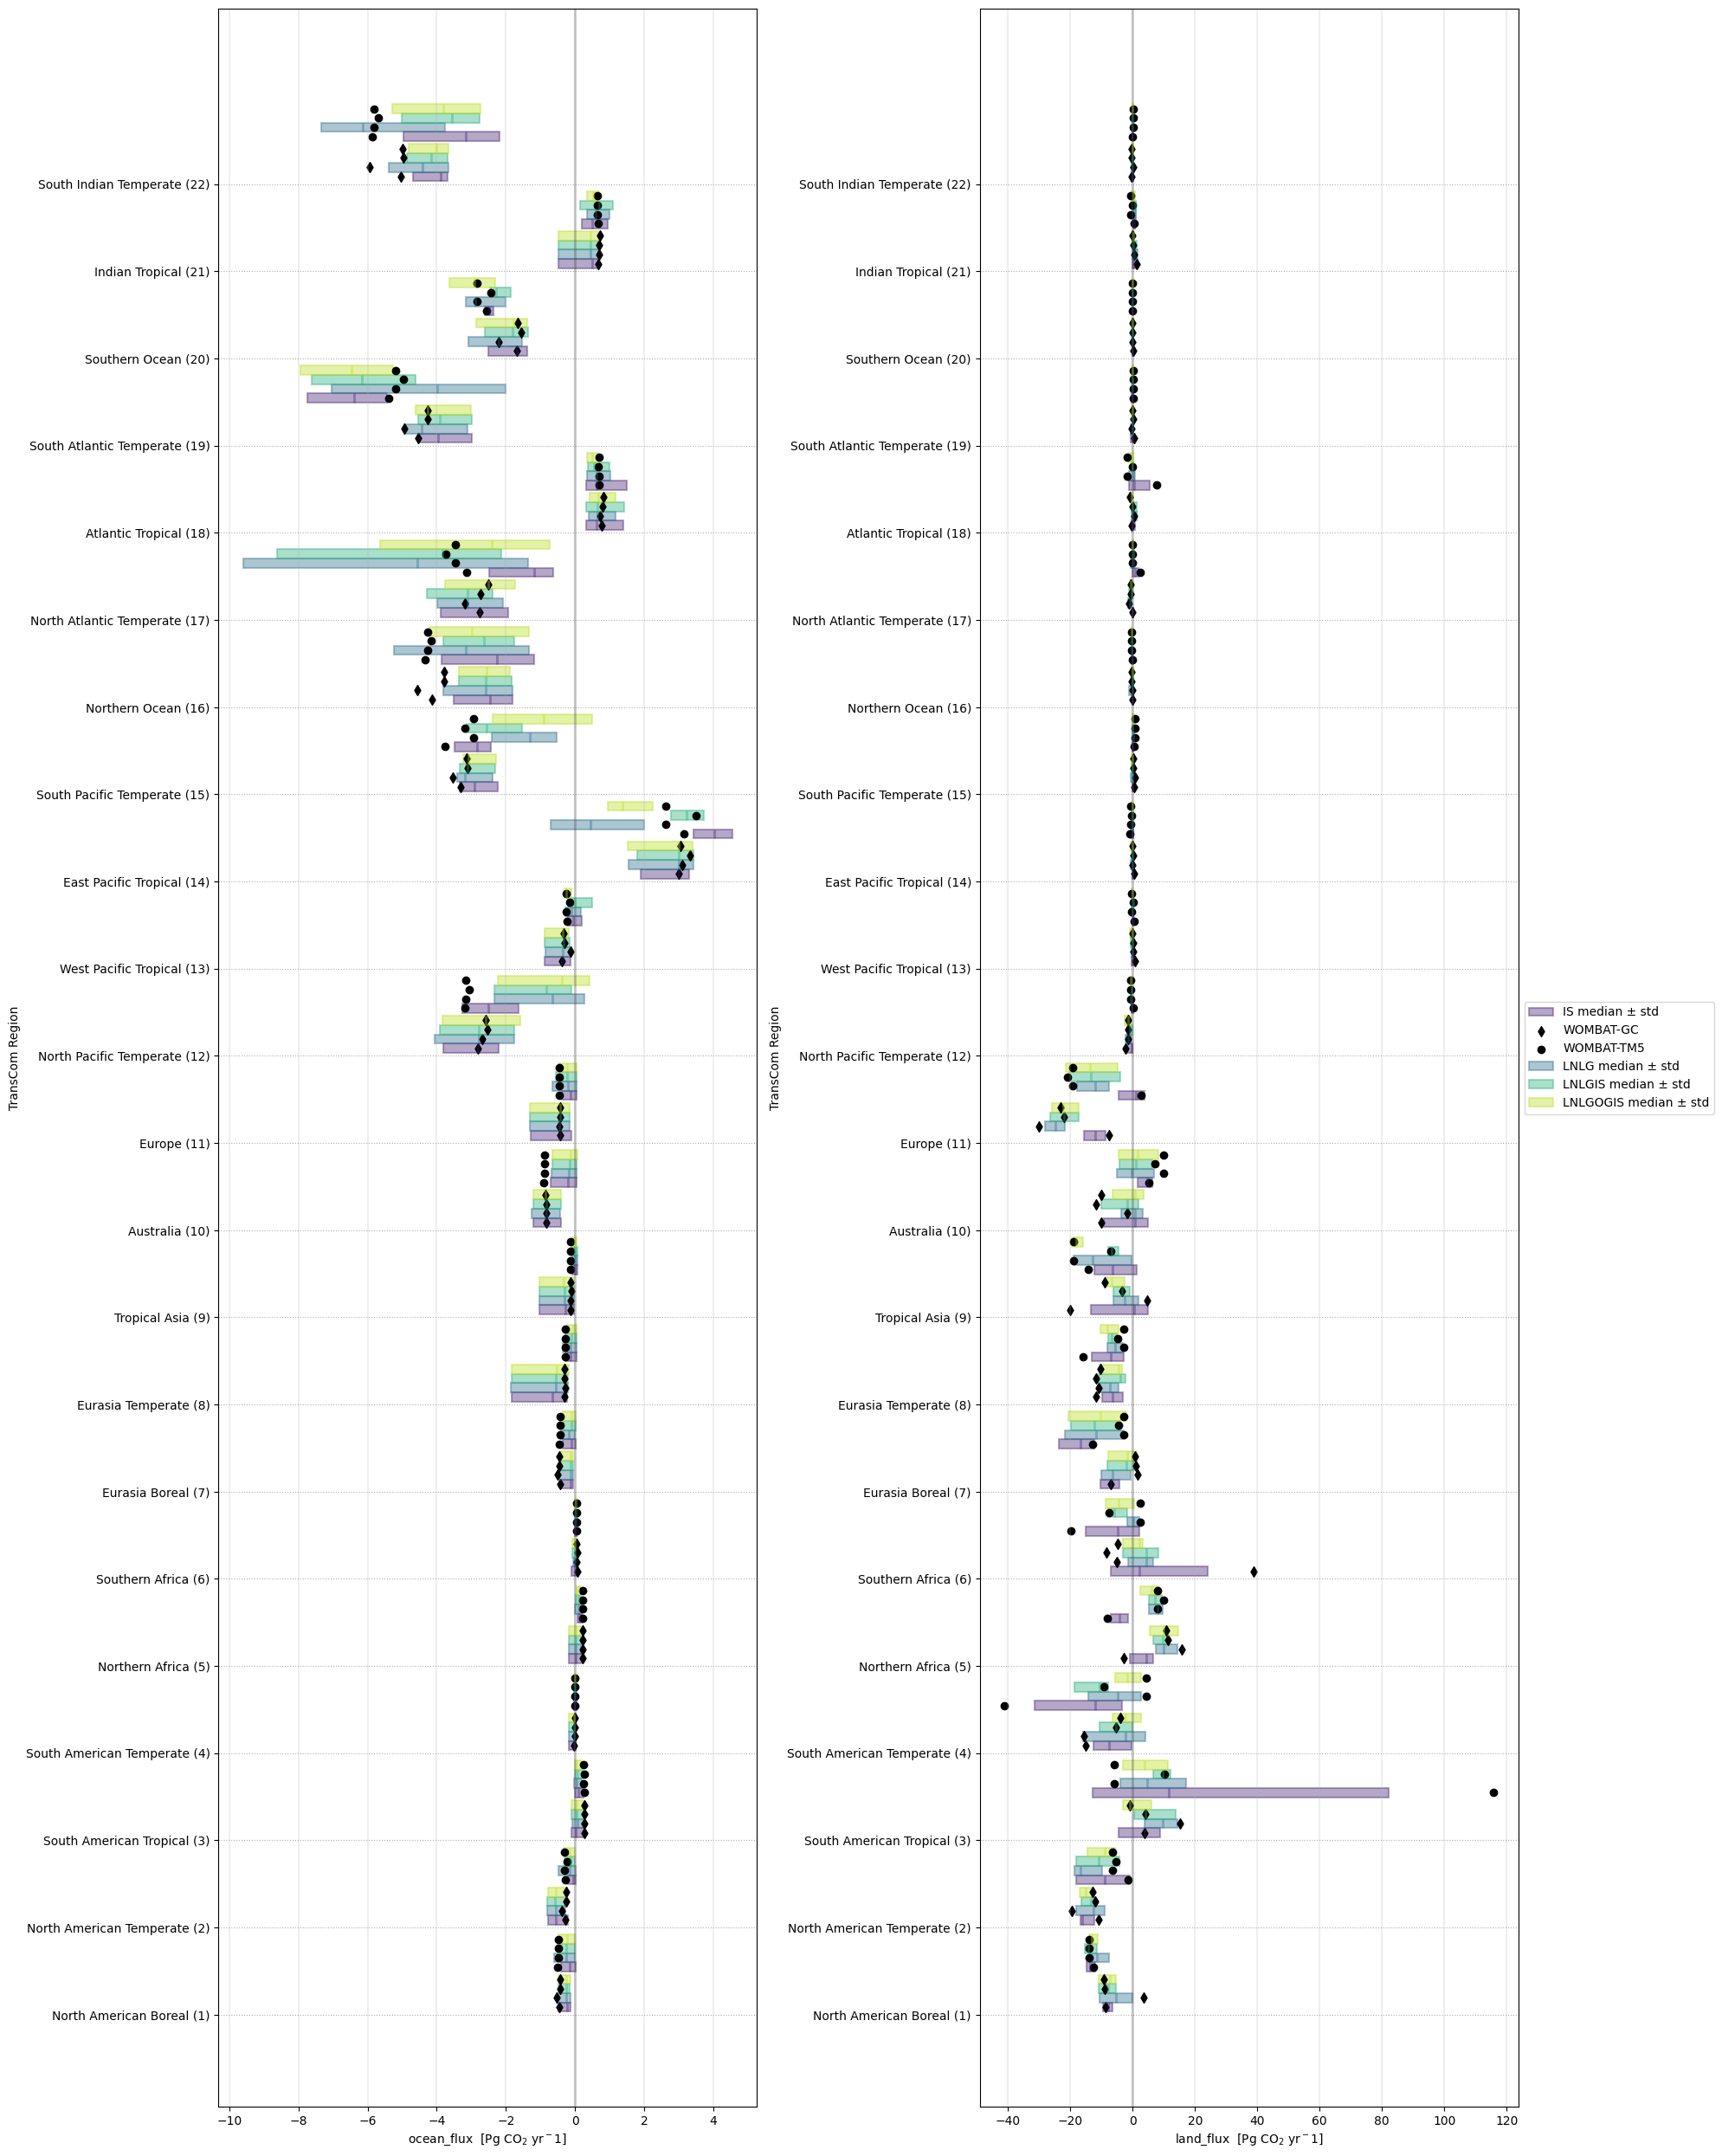

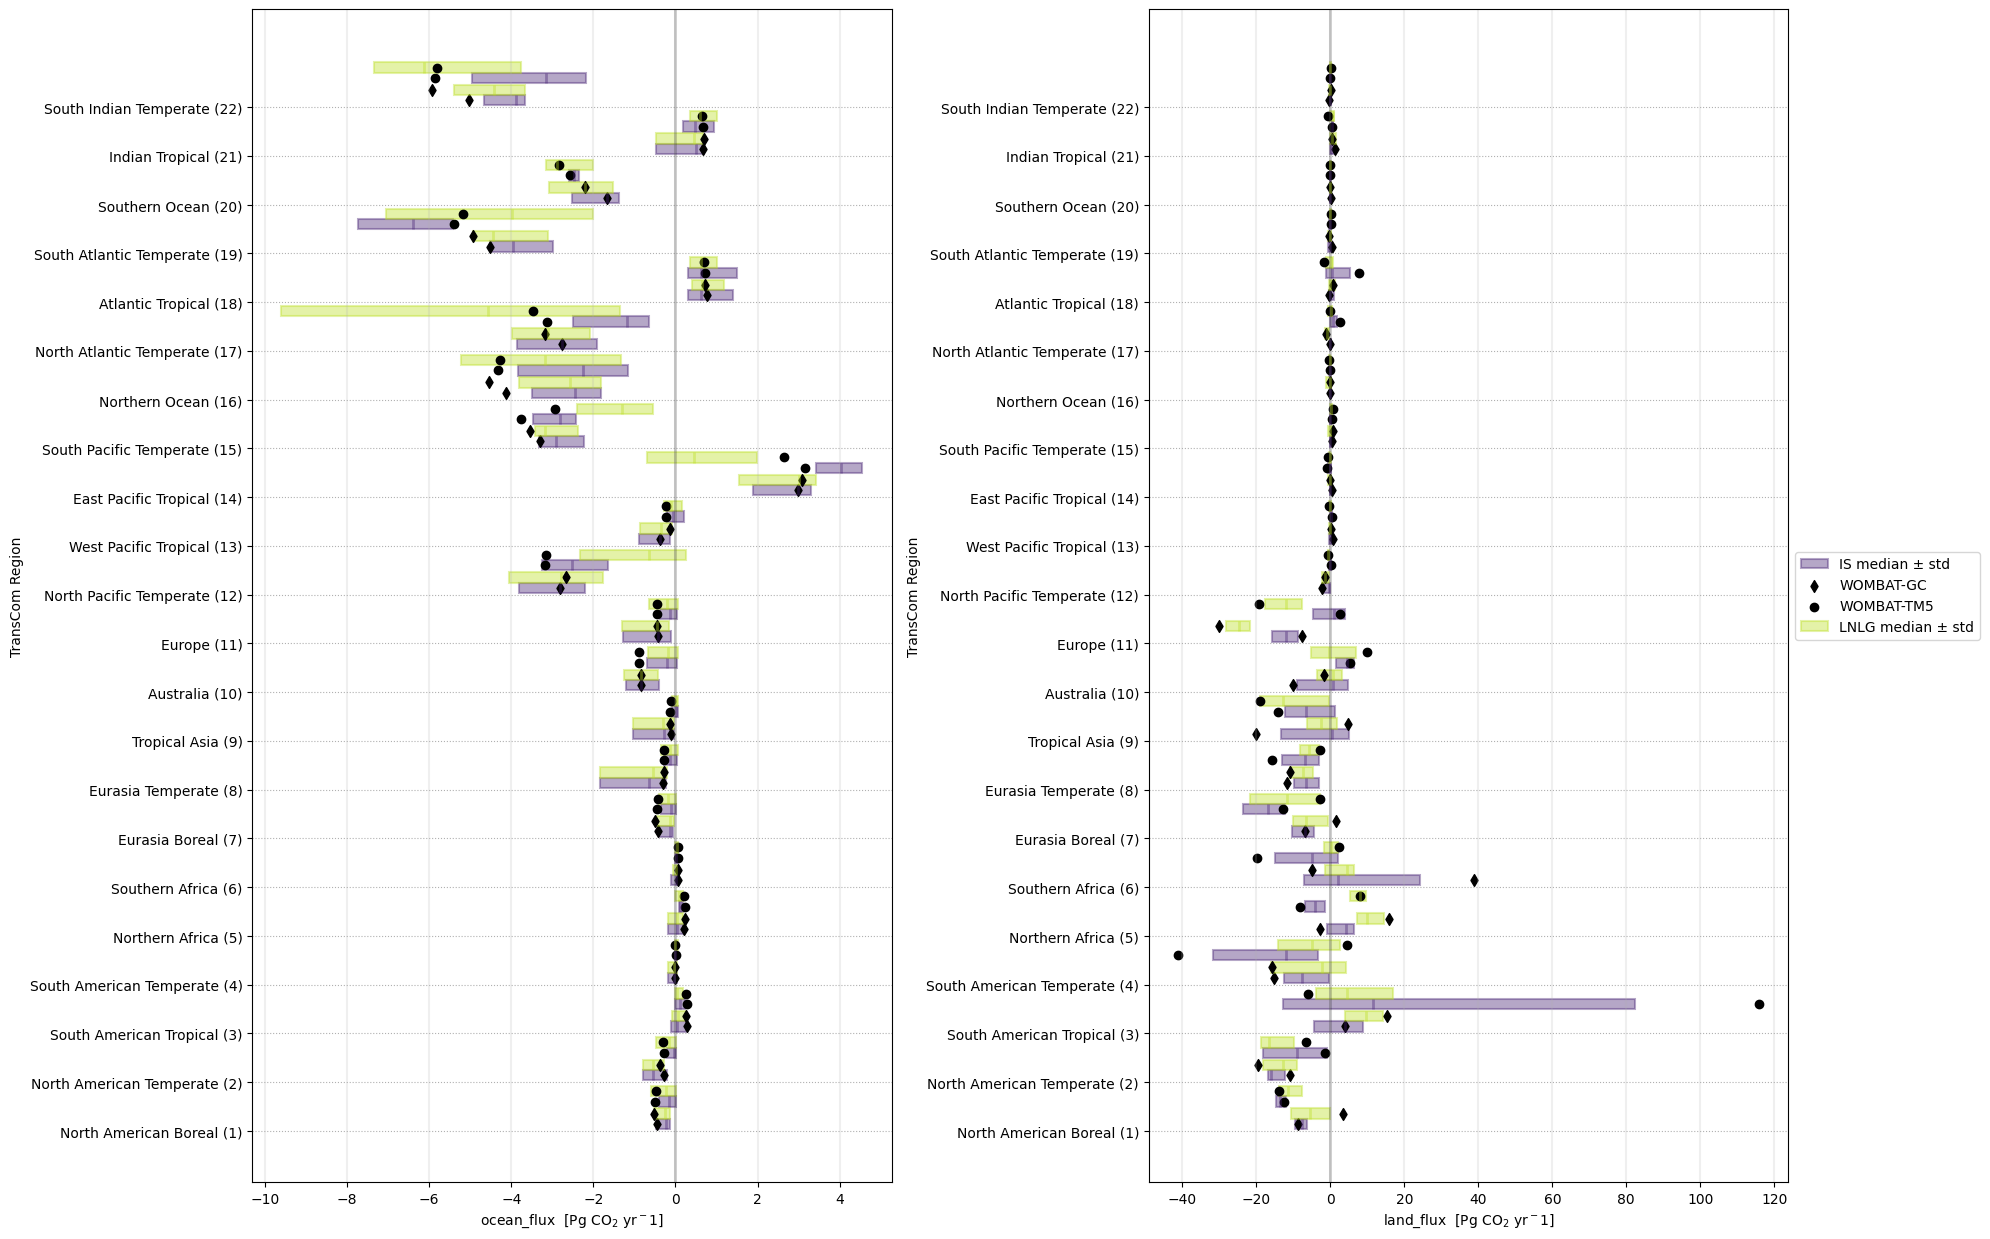

In [6]:
# ---------- compute net climatological fluxes per latitude band, as ensemble mean, transport ensemble means, WOMBAT

def make_avgflux_transcom_plot(include_obs, fname):
    
    # ----- get transcom regions
    map = xr.open_dataset('../iregions.nc')
    map = map.rename({'lat': 'latitude', 'lon':'longitude'})
    tcr = map['transcom_regions']
    all_regions =  sorted(np.unique(tcr).astype(int))[:-1]
    Nregions = len(all_regions)
    region_names = [''.join(x.decode("utf-8") for x in map['transcom_names'].sel({'dim_transcom23':region}).values).strip()+f' ({region})' 
                    for region in all_regions]
    print(region_names)
    
    include_ensmean = False
    if(include_ensmean): ng = 3
    else:                ng = 2

    dy    = 1/Nregions
    Nobs  = len(include_obs)
    pad   = 0.005
    ddy   = dy/(Nobs*ng) - pad/(Nobs*ng)
    
    # ----- defined colors per obs ser
    colors = np.atleast_1d(plt.cm.viridis(np.linspace(0.1, 0.9, Nobs)))
    
    # ----- create figure
    fig, axes = plt.subplots(1, 2, figsize=(20, 25 * len(include_obs)/4))
    
    # ----- compute medians and deviations for model groups in regions
    for k,flux in enumerate(['ocean_flux', 'land_flux']):
    #for k,flux in enumerate(['ocean_flux']):
        print(f'working on {flux} flux')
        ax = axes[k]
        ax.yaxis.set_ticks(np.linspace(0, 1, Nregions))
        ax.yaxis.set_ticklabels(region_names)
        ax.grid(axis='y', linestyle=':')
        ax.grid(axis='x', linestyle='-', alpha=0.2, lw=1.5)
        ax.axvline(x=0, linestyle='-', color='k', lw=2, alpha=0.2)
        ax.set_xlabel(f'{flux}  [Pg CO$_2$ yr$^{-1}$]')
        ax.set_ylabel('TransCom Region')
        
        for i,region in enumerate(all_regions):
            print(f'working on transcom region {i}', end='\r')
            
            for j,obs in enumerate(include_obs):
                if obs == 'Prior': continue

                # get time mean, 2015-2019
                region_ens = ens[obs][flux].sel(time=slice('2015-01-01', '2020-01-01')).mean('time') * 100
                region_gc_ens = ens_gc[obs][flux].sel(time=slice('2015-01-01', '2020-01-01')).mean('time') * 100
                region_tm5_ens = ens_tm5[obs][flux].sel(time=slice('2015-01-01', '2020-01-01')).mean('time') * 100
    
                # select on obs, flux, take region mean, take time mean, scale to PgC/yr
                region_ens     = horz_avg(region_ens.where(tcr==region))
                region_gc_ens  = horz_avg(region_gc_ens.where(tcr==region))
                region_tm5_ens = horz_avg(region_tm5_ens.where(tcr==region))
    
                if(include_ensmean):
                    region_ens_all = [region_gc_ens, region_tm5_ens, region_ens]
                else:
                    region_ens_all = [region_gc_ens, region_tm5_ens]
    
                for l in range(ng):
                    # get medians, deviations, lower y-position of bar
                    y = np.linspace(0, 1, Nregions)[i] + (j+l*Nobs)*ddy + pad/(ng+1) * (l+1)
                    x  = float(region_ens_all[l].median('model'))
                    xm = float(region_ens_all[l].mean('model'))
                    xe = float(region_ens_all[l].std('model'))
        
                    # get colors
                    fcolor = colors[j]
                    fcolor[-1] = 0.4
                    ecolor = colors[j]

                    # get labels
                    if(i==0 and k==1 and l==0): label = f'{obs} median ± std'
                    else:     label = None
        
                    # rectangle showing uncertainty and median
                    rect = Rectangle(
                           (xm - xe, y),  # bottom-left corner
                           2*xe, ddy,  # width and height
                           facecolor=fcolor, edgecolor=ecolor, linewidth=1.5, label=label)
                    ax.add_patch(rect)
                    # center vertical line
                    ax.vlines(x, y, y+ddy, color=ecolor, linewidth=2)
    
                    # plot WOMBAT
                    y = y + ddy/2
                    if(l==0):   
                        x = region_ens.sel(model='WOMBAT-GC')
                        marker='d'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-GC'
                        else:              label = None
                    elif(l==1): 
                        x = region_ens.sel(model='WOMBAT-TM5')
                        marker='o'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-TM5'
                        else:              label = None
                    else:
                        x = 0
                        marker=''
                    ax.scatter(x, y, color='k', marker=marker, label=label)

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    fig.savefig(f'{fname}.png', dpi=200)
                    
# -------------------------------------------------
# --------- call function and make plots ----------
make_avgflux_transcom_plot(['IS', 'LNLG', 'LNLGIS', 'LNLGOGIS'], fname='avgflux_transcom_allobs')
make_avgflux_transcom_plot(['IS', 'LNLG'], fname='avgflux_transcom_IS_LNLG')